# B2 — Model Training & Experiment Tracking
**KUru: KU Curriculum & PLO Navigator**

This notebook implements the RAG pipeline as a trainable ML model:

| ML concept | RAG equivalent |
|-----------|----------------|
| Training data | 13,910 cleaned document chunks in Supabase pgvector (57 program records after duplicate cleanup) |
| Model architecture | multilingual-e5-base → IVFFlat index → same-program keyword fallback + targeted lexical reranker → Gemini 2.5 Flash Lite via OpenRouter |
| Hyperparameters | `top_k`, `MIN_SIMILARITY`, `chunk_size`, `overlap` |
| Training loop | Eval run over 50-question golden set with LLM-as-judge |
| Validation metric | Average LLM-judge score (0–3), % good answers (score ≥ 2) |
| Experiment tracking | MLflow — 3 configurations logged with params + metrics |

**Includes B3 fairness analysis**: per-program and section-type score breakdown.

**Eval set**: `data/eval_set_v2.csv` (50 synthetic Q&A pairs, v2 quality — program-named questions)  
**Judge model**: `google/gemini-2.5-flash-lite` via OpenRouter  
**Sample per run**: 20 questions (random seed 42)

In [1]:
import os
import sys
import csv
import json
import random
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import mlflow
from dotenv import load_dotenv

# Add project root to path so kuru package is importable
project_root = Path('..').resolve()
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

load_dotenv(dotenv_path='../.env')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

EVAL_CSV   = '../data/eval_set_v2.csv'
RESULTS_DIR = Path('../data')
FIGURES_DIR = Path('../docs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
SAMPLE_SIZE = 20

print('Setup complete ✓')
print(f'MLflow version: {mlflow.__version__}')
print(f'Eval CSV: {EVAL_CSV}')

Setup complete ✓
MLflow version: 3.12.0
Eval CSV: ../data/eval_set_v2.csv


## 1. Data Preprocessing — Eval Set Preparation

The eval set is the **validation dataset** for our RAG model. Preprocessing steps:
1. Load and parse the CSV
2. Validate required columns are present
3. Encode question types (categorical → integer label)
4. Sample 20 questions with fixed seed (reproducible across all 3 experiment runs)
5. Inspect missing values and balance

In [2]:
# ── 1.1 Load eval set ─────────────────────────────────────────────────────────
eval_df = pd.read_csv(EVAL_CSV, encoding='utf-8')

print(f'Eval set loaded: {len(eval_df)} rows')
print(f'Columns: {list(eval_df.columns)}')
print()

# ── 1.2 Validate required columns ─────────────────────────────────────────────
REQUIRED_COLS = ['question', 'ground_truth_answer', 'question_type', 'program_id', 'section_type']
missing_cols = [c for c in REQUIRED_COLS if c not in eval_df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')
print('Required columns: OK ✓')

# ── 1.3 Handle missing values ──────────────────────────────────────────────────
print('\nMissing values:')
print(eval_df[REQUIRED_COLS].isna().sum().to_string())

eval_df['question_type'] = eval_df['question_type'].fillna('unknown')
eval_df['section_type']  = eval_df['section_type'].fillna('unknown')
eval_df['program_id']    = eval_df['program_id'].fillna('')

# ── 1.4 Encode question_type as integer label ──────────────────────────────────
qtype_categories = sorted(eval_df['question_type'].unique())
qtype_to_int = {qt: i for i, qt in enumerate(qtype_categories)}
eval_df['question_type_code'] = eval_df['question_type'].map(qtype_to_int)

print(f'\nQuestion type encoding:')
for qt, code in qtype_to_int.items():
    n = (eval_df['question_type'] == qt).sum()
    print(f'  {code}: {qt:15s}  ({n} questions)')

# ── 1.5 Stratified sample — same 20 questions used in ALL 3 experiments ────────
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
sample_idx = random.sample(range(len(eval_df)), min(SAMPLE_SIZE, len(eval_df)))
eval_sample = eval_df.iloc[sample_idx].reset_index(drop=True)

print(f'\nSampled {len(eval_sample)} questions (seed={RANDOM_SEED})')
print('Sample question_type distribution:')
print(eval_sample['question_type'].value_counts().to_string())

Eval set loaded: 50 rows
Columns: ['question', 'ground_truth_answer', 'question_type', 'source_file', 'program_id', 'section_type']

Required columns: OK ✓

Missing values:
question               0
ground_truth_answer    0
question_type          0
program_id             0
section_type           0

Question type encoding:
  0: admission        (12 questions)
  1: curriculum       (31 questions)
  2: general          (5 questions)
  3: plo              (2 questions)

Sampled 20 questions (seed=42)
Sample question_type distribution:
question_type
curriculum    14
admission      6


## 2. Model Architecture Definition

The KUru RAG pipeline is a **sequential multi-component model**:

```
Query
  └─► [Embedder]          multilingual-e5-base (768-dim, local)
        └─► [Retriever]   pgvector IVFFlat similarity search
              └─► [Reranker]  PyThaiNLP token overlap boost
                    └─► [Guard]  no-data filter (MIN_SIMILARITY threshold)
                          └─► [Generator]  Gemini 2.5 Flash Lite
```

### Hyperparameters

| Hyperparameter | Role | Impact |
|---------------|------|--------|
| `top_k` | Number of chunks returned to LLM | Higher → more context, slower + costlier |
| `MIN_SIMILARITY` | Minimum cosine similarity to include chunk | Higher → stricter relevance filter |
| `fetch_multiplier` | Fetches `top_k × N` chunks before reranking | Higher → better reranking pool |
| `chunk_size` | Max characters per chunk at ingestion | Baked in at ingest time — fixed for these experiments |
| `overlap` | Shared characters between adjacent chunks | Baked in at ingest time — fixed |

For these 3 experiments we vary `top_k` and `MIN_SIMILARITY` against the **existing ingested corpus** (no re-ingestion needed).

In [3]:
# ── Model architecture constants (fixed across all experiments) ────────────────
ARCHITECTURE = {
    'embed_model':       'intfloat/multilingual-e5-base',
    'embed_dim':         768,
    'embed_prefix_doc':  'passage:',
    'embed_prefix_query':'query:',
    'index_type':        'IVFFlat',
    'index_probes':      10,
    'chunk_size':        2000,
    'chunk_overlap':     200,
    'fetch_multiplier':  3,       # fetch top_k × 3 before reranking
    'generator_model':   'google/gemini-2.5-flash-lite',
    'reranker':          'pythainlp-token-overlap',
    'total_chunks':      13910,
    'total_programs':    66,
}

# ── 3 experiment configurations (hyperparameters to tune) ─────────────────────
EXPERIMENTS = [
    {
        'run_name':     'baseline',
        'description':  'Production defaults: top_k=5, MIN_SIMILARITY=0.35',
        'top_k':        5,
        'min_similarity': 0.35,
        'out_csv':      '../data/eval_results_exp1.csv',
    },
    {
        'run_name':     'wider_retrieval',
        'description':  'Wider context: top_k=8 + softer threshold (0.30) — more chunks reach LLM',
        'top_k':        8,
        'min_similarity': 0.30,
        'out_csv':      '../data/eval_results_exp2.csv',
    },
    {
        'run_name':     'strict_threshold',
        'description':  'Stricter filter: top_k=5, MIN_SIMILARITY=0.45 — only high-confidence chunks',
        'top_k':        5,
        'min_similarity': 0.45,
        'out_csv':      '../data/eval_results_exp3.csv',
    },
]

print('Architecture:')
for k, v in ARCHITECTURE.items():
    print(f'  {k:22s} = {v}')

print(f'\n{len(EXPERIMENTS)} experiment configurations defined:')
for i, exp in enumerate(EXPERIMENTS, 1):
    print(f'  Exp {i} [{exp["run_name"]}]: top_k={exp["top_k"]}, MIN_SIMILARITY={exp["min_similarity"]} — {exp["description"]}')

Architecture:
  embed_model            = intfloat/multilingual-e5-base
  embed_dim              = 768
  embed_prefix_doc       = passage:
  embed_prefix_query     = query:
  index_type             = IVFFlat
  index_probes           = 10
  chunk_size             = 2000
  chunk_overlap          = 200
  fetch_multiplier       = 3
  generator_model        = google/gemini-2.5-flash-lite
  reranker               = pythainlp-token-overlap
  total_chunks           = 13910
  total_programs         = 66

3 experiment configurations defined:
  Exp 1 [baseline]: top_k=5, MIN_SIMILARITY=0.35 — Production defaults: top_k=5, MIN_SIMILARITY=0.35
  Exp 2 [wider_retrieval]: top_k=8, MIN_SIMILARITY=0.3 — Wider context: top_k=8 + softer threshold (0.30) — more chunks reach LLM
  Exp 3 [strict_threshold]: top_k=5, MIN_SIMILARITY=0.45 — Stricter filter: top_k=5, MIN_SIMILARITY=0.45 — only high-confidence chunks


## 3. Training Loop — Evaluation Function

In the RAG framing, the "training loop" is a **validation pass** over the eval set:

1. For each question in the sample, call `query(question, top_k=..., program_id=...)` with the experiment's hyperparameters
2. Score the answer using the LLM judge (0–3 scale)
3. Log metrics with MLflow
4. Save per-question results to CSV

The inner loop mirrors a mini-batch SGD pass — each question is a "sample", the score is "loss" (inverted: higher score = lower loss).

In [4]:
from kuru.llm import GENERATION_MODEL, get_openrouter_client, session_usage
from kuru.rag.query_engine import query as rag_query

print(f'Generation model (judge): {GENERATION_MODEL}')

# ── LLM judge ─────────────────────────────────────────────────────────────────
_JUDGE_SYSTEM = """You are an expert evaluator for a Thai university RAG chatbot.
Score the RAG answer against the ground truth on a 0-3 scale:
3 = Correct and complete: covers all key facts in ground truth
2 = Partially correct: main point addressed but details missing or minor errors
1 = Tangentially related: on-topic but does not directly answer the question
0 = Wrong or hallucinated: contradicts ground truth or invents facts
Output valid JSON only: {"score": <0|1|2|3>, "reasoning": "<one short sentence>"}"""

def _judge(question: str, ground_truth: str, rag_answer: str) -> tuple[int, str]:
    prompt = f"Question: {question}\n\nGround truth: {ground_truth}\n\nRAG answer: {rag_answer}"
    try:
        resp = get_openrouter_client().chat.completions.create(
            model=GENERATION_MODEL,
            messages=[
                {'role': 'system', 'content': _JUDGE_SYSTEM},
                {'role': 'user',   'content': prompt},
            ],
            temperature=0.0, max_tokens=200,
        )
        if resp.usage:
            session_usage.add(GENERATION_MODEL, resp.usage)
        raw = (resp.choices[0].message.content or '').strip()
        if raw.startswith('```'):
            raw = raw.split('```')[1]
            if raw.startswith('json'): raw = raw[4:]
        parsed = json.loads(raw)
        return int(parsed['score']), str(parsed.get('reasoning', ''))
    except Exception as exc:
        return -1, f'judge error: {exc}'


def run_experiment(exp: dict, sample: pd.DataFrame, delay: float = 0.5) -> pd.DataFrame:
    """Run one eval pass with the given hyperparameters. Returns per-question results df."""
    top_k   = exp['top_k']
    min_sim = exp['min_similarity']
    out_csv = Path(exp['out_csv'])

    # Monkey-patch the module-level constants so query() picks them up
    import kuru.rag.query_engine as qe
    orig_top_k   = qe.TOP_K
    orig_min_sim = qe.MIN_SIMILARITY
    qe.TOP_K          = top_k
    qe.MIN_SIMILARITY = min_sim

    rows = []
    scores = []

    print(f'\n>>> {exp["run_name"]}  top_k={top_k}  MIN_SIMILARITY={min_sim}')
    print(f'    {exp["description"]}')
    print(f'    Output: {out_csv}')
    print()

    try:
        for i, row in sample.iterrows():
            question     = row['question']
            ground_truth = row['ground_truth_answer']
            program_id   = row['program_id'] or None
            q_type       = row['question_type']
            section      = row['section_type']

            print(f'  [{len(rows)+1:02d}/{len(sample)}] {question[:55]:55s}', end=' ', flush=True)

            # RAG query
            try:
                rag_result = rag_query(question, top_k=top_k, program_id=program_id)
                rag_answer = rag_result.answer
                sources    = '|'.join(s.get('source_file', '') for s in rag_result.sources[:3])
                n_chunks   = len(rag_result.sources)
                top_score  = rag_result.sources[0].get('similarity', 0.0) if rag_result.sources else 0.0
            except Exception as exc:
                rag_answer = f'[RAG error: {exc}]'
                sources    = ''
                n_chunks   = 0
                top_score  = 0.0

            # Judge
            score, reasoning = _judge(question, ground_truth, rag_answer)
            scores.append(score)

            label = {3: '✓✓', 2: '✓ ', 1: '~ ', 0: '✗ ', -1: '??'}.get(score, '??')
            print(f'→ {label} {score}')

            rows.append({
                'question':            question,
                'ground_truth_answer': ground_truth,
                'rag_answer':          rag_answer,
                'score':               score,
                'reasoning':           reasoning,
                'question_type':       q_type,
                'section_type':        section,
                'program_id':          row['program_id'],
                'sources_used':        sources,
                'n_chunks_returned':   n_chunks,
                'top_similarity':      round(top_score, 4),
                'run_name':            exp['run_name'],
                'top_k':               top_k,
                'min_similarity':      min_sim,
            })

            if delay and len(rows) < len(sample):
                time.sleep(delay)

    finally:
        # Always restore original constants
        qe.TOP_K          = orig_top_k
        qe.MIN_SIMILARITY = orig_min_sim

    results_df = pd.DataFrame(rows)
    results_df.to_csv(out_csv, index=False, encoding='utf-8')

    # Summary
    valid = [s for s in scores if s >= 0]
    if valid:
        avg = sum(valid) / len(valid)
        dist = {s: valid.count(s) for s in range(4)}
        pct_good = (dist[2] + dist[3]) / len(valid) * 100
        print(f'\n  avg={avg:.2f}  good={pct_good:.0f}%  dist={dist}')

    return results_df


print('Evaluation functions defined ✓')

Generation model (judge): google/gemini-2.5-flash-lite
Evaluation functions defined ✓


## 4. Run 3 Experiments with MLflow Tracking

Each experiment is one MLflow run. Logged:
- **Params**: `top_k`, `min_similarity`, `fetch_multiplier`, `embed_model`, `generator_model`, `chunk_size`, `chunk_overlap`, `sample_size`
- **Metrics**: `avg_score`, `pct_good`, `n_score_3`, `n_score_2`, `n_score_1`, `n_score_0`, `avg_score_curriculum`, `avg_score_admission`

> **Note**: This cell makes ~40 API calls (20 RAG + 20 judge per experiment × 3 experiments). Estimated cost: ~$0.03 total.

In [5]:
MLFLOW_EXPERIMENT = 'kuru-rag-hyperparameter-search'
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment(MLFLOW_EXPERIMENT)

all_results = {}  # run_name → DataFrame

for exp in EXPERIMENTS:
    with mlflow.start_run(run_name=exp['run_name']) as run:
        # ── Log hyperparameters ────────────────────────────────────────────────
        mlflow.log_params({
            # Tuned hyperparameters
            'top_k':            exp['top_k'],
            'min_similarity':   exp['min_similarity'],
            'fetch_multiplier': ARCHITECTURE['fetch_multiplier'],
            # Fixed architecture params
            'embed_model':      ARCHITECTURE['embed_model'],
            'embed_dim':        ARCHITECTURE['embed_dim'],
            'generator_model':  ARCHITECTURE['generator_model'],
            'chunk_size':       ARCHITECTURE['chunk_size'],
            'chunk_overlap':    ARCHITECTURE['chunk_overlap'],
            'index_type':       ARCHITECTURE['index_type'],
            'index_probes':     ARCHITECTURE['index_probes'],
            'reranker':         ARCHITECTURE['reranker'],
            'sample_size':      SAMPLE_SIZE,
            'random_seed':      RANDOM_SEED,
            'description':      exp['description'],
        })

        # ── Training loop (eval pass) ──────────────────────────────────────────
        results_df = run_experiment(exp, eval_sample, delay=0.5)
        all_results[exp['run_name']] = results_df

        # ── Compute and log metrics ────────────────────────────────────────────
        valid_scores = results_df[results_df['score'] >= 0]['score'].tolist()
        if valid_scores:
            avg_score = sum(valid_scores) / len(valid_scores)
            dist = {s: valid_scores.count(s) for s in range(4)}
            pct_good  = (dist[2] + dist[3]) / len(valid_scores) * 100

            # Breakdown by question type
            by_type = results_df[results_df['score'] >= 0].groupby('question_type')['score'].mean()

            metrics = {
                'avg_score':              round(avg_score, 3),
                'pct_good':               round(pct_good, 1),
                'n_score_3':              dist[3],
                'n_score_2':              dist[2],
                'n_score_1':              dist[1],
                'n_score_0':              dist[0],
                'n_valid':                len(valid_scores),
                'avg_top_similarity':     round(results_df['top_similarity'].mean(), 4),
                'avg_n_chunks_returned':  round(results_df['n_chunks_returned'].mean(), 2),
            }
            for qtype, avg in by_type.items():
                metrics[f'avg_score_{qtype}'] = round(avg, 3)

            mlflow.log_metrics(metrics)

        # ── Log results CSV as artifact ────────────────────────────────────────
        mlflow.log_artifact(exp['out_csv'], artifact_path='eval_results')

        print(f'\n  MLflow run_id: {run.info.run_id}')

print('\n=== All 3 experiments complete ===')

2026/05/14 00:31:59 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/14 00:32:00 INFO mlflow.store.db.utils: Updating database tables
2026/05/14 00:32:25 INFO mlflow.tracking.fluent: Experiment with name 'kuru-rag-hyperparameter-search' does not exist. Creating a new experiment.



>>> baseline  top_k=5  MIN_SIMILARITY=0.35
    Production defaults: top_k=5, MIN_SIMILARITY=0.35
    Output: ..\data\eval_results_exp1.csv

  [01/20] ระบบการรับนิสิตของหลักสูตรวิทยาศาสตรบัณฑิต สาขาวิชา วนศ 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

→ ✓  2
  [02/20] What does the course 'Curriculum Development' (01162212 → ✓✓ 3
  [03/20] For the Chemical Engineering program at KU, how many cr → ✗  0
  [04/20] Does the นานาชาติ program at Kasetsart University accep → ✗  0
  [05/20] How many credits are required for the 'Languages and Co → ✓✓ 3
  [06/20] ในหมวดวิชาศึกษาทั่วไปของหลักสูตรวิศวกรรมโยธา ต้องเรียนก → ✓✓ 3
  [07/20] การรับนิสิตเข้าศึกษาในหลักสูตรวิทยาศาสตรบัณฑิต สาขาวิชา → ✓  2
  [08/20] What are the core concepts covered in the 'Education fo → ✓✓ 3
  [09/20] หลักสูตรรัฐประศาสนศาสตร์ ของ มก. รับนิสิตประเภทใดบ้าง?  → ✓  2
  [10/20] What is the minimum credit requirement for the 'Languag → ✓✓ 3
  [11/20] What is the minimum credit requirement for the 'General → ✗  0
  [12/20] For the Materials Engineering program at KU, what is th → ✓✓ 3
  [13/20] ในหลักสูตรวิศวกรรมคอมพิวเตอร์ ต้องเรียนหมวดวิชาศึกษาทั่ → ✓✓ 3
  [14/20] นิสิตหลักสูตรสัตวศาสตร์อุตสาหกรรม ที่สนใจไปศึกษาแลกเปลี → ✓✓ 3
  [15/20] What is the minimum credit require

## 5. Results Analysis — Compare Experiments

Aggregate results across all 3 runs and produce summary tables and charts.

In [6]:
# ── Load from saved CSVs (reproducible even if the cell above was already run) ─
loaded = {}
for exp in EXPERIMENTS:
    path = Path(exp['out_csv'])
    if path.exists():
        loaded[exp['run_name']] = pd.read_csv(path, encoding='utf-8')
    else:
        print(f'WARNING: {path} not found — run Section 4 first')

if not loaded:
    raise RuntimeError('No experiment results found. Run Section 4 first.')

# ── Build summary table ────────────────────────────────────────────────────────
summary_rows = []
for exp in EXPERIMENTS:
    df = loaded.get(exp['run_name'])
    if df is None: continue
    valid = df[df['score'] >= 0]['score']
    if len(valid) == 0: continue
    dist = valid.value_counts().to_dict()
    pct_good = (dist.get(2, 0) + dist.get(3, 0)) / len(valid) * 100
    summary_rows.append({
        'Run':             exp['run_name'],
        'top_k':           exp['top_k'],
        'MIN_SIMILARITY':  exp['min_similarity'],
        'Avg Score':       round(valid.mean(), 2),
        '% Good (≥2)':     round(pct_good, 1),
        'Score 3':         dist.get(3, 0),
        'Score 2':         dist.get(2, 0),
        'Score 1':         dist.get(1, 0),
        'Score 0':         dist.get(0, 0),
        'N':               len(valid),
    })

summary_df = pd.DataFrame(summary_rows)
print('=== Experiment Summary ===')
print(summary_df.to_string(index=False))

=== Experiment Summary ===
             Run  top_k  MIN_SIMILARITY  Avg Score  % Good (≥2)  Score 3  Score 2  Score 1  Score 0  N
        baseline      5            0.35       1.75         65.0        8        5        1        6 20
 wider_retrieval      8            0.30       1.85         65.0        9        4        2        5 20
strict_threshold      5            0.45       1.80         65.0        9        4        1        6 20


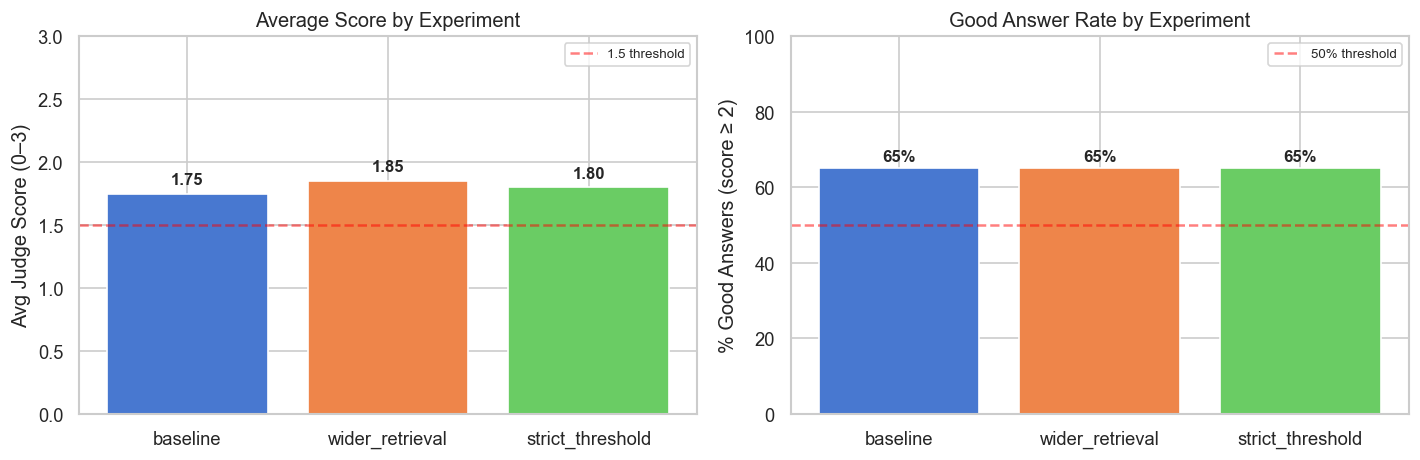

In [7]:
# ── Figure 1: Avg score + % good bar chart ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

run_labels = [r['Run'] for r in summary_rows]
avg_scores  = [r['Avg Score'] for r in summary_rows]
pct_goods   = [r['% Good (≥2)'] for r in summary_rows]
colors = sns.color_palette('muted', len(run_labels))

bars1 = axes[0].bar(run_labels, avg_scores, color=colors)
axes[0].axhline(1.5, color='red', linestyle='--', alpha=0.5, label='1.5 threshold')
axes[0].set_ylim(0, 3.0)
axes[0].set_ylabel('Avg Judge Score (0–3)')
axes[0].set_title('Average Score by Experiment')
axes[0].legend(fontsize=8)
for bar, val in zip(bars1, avg_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(run_labels, pct_goods, color=colors)
axes[1].axhline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('% Good Answers (score ≥ 2)')
axes[1].set_title('Good Answer Rate by Experiment')
axes[1].legend(fontsize=8)
for bar, val in zip(bars2, pct_goods):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'B2_experiment_comparison.png', bbox_inches='tight')
plt.show()

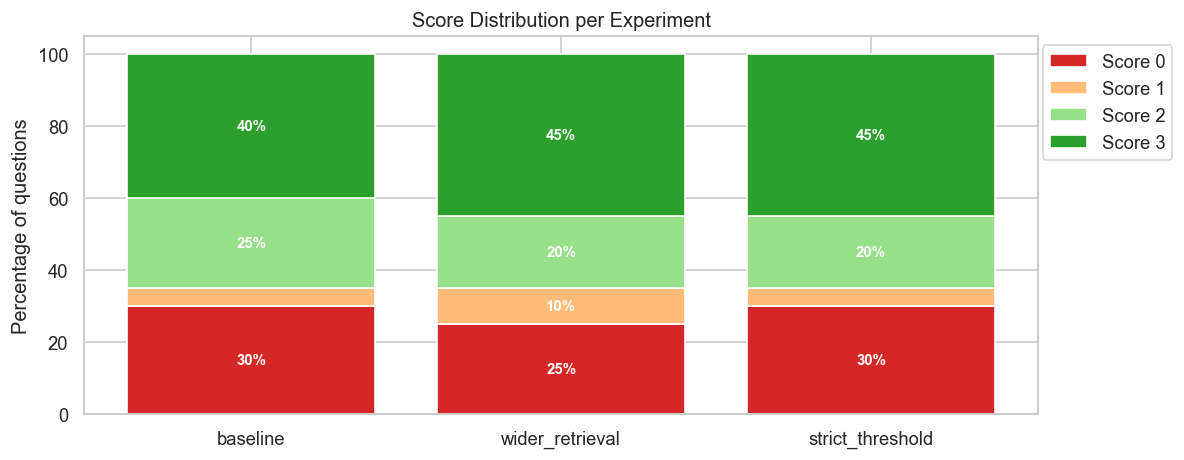

In [8]:
# ── Figure 2: Score distribution stacked bar ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

score_colors = {3: '#2ca02c', 2: '#98df8a', 1: '#ffbb78', 0: '#d62728'}
bottoms = [0] * len(summary_rows)

for score in [0, 1, 2, 3]:
    counts = [r[f'Score {score}'] for r in summary_rows]
    pcts   = [c / r['N'] * 100 for c, r in zip(counts, summary_rows)]
    ax.bar(run_labels, pcts, bottom=bottoms, color=score_colors[score],
           label=f'Score {score}', edgecolor='white')
    for j, (p, bot) in enumerate(zip(pcts, bottoms)):
        if p > 5:
            ax.text(j, bot + p/2, f'{int(round(p))}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    bottoms = [b + p for b, p in zip(bottoms, pcts)]

ax.set_ylim(0, 105)
ax.set_ylabel('Percentage of questions')
ax.set_title('Score Distribution per Experiment')
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'B2_score_distribution.png', bbox_inches='tight')
plt.show()

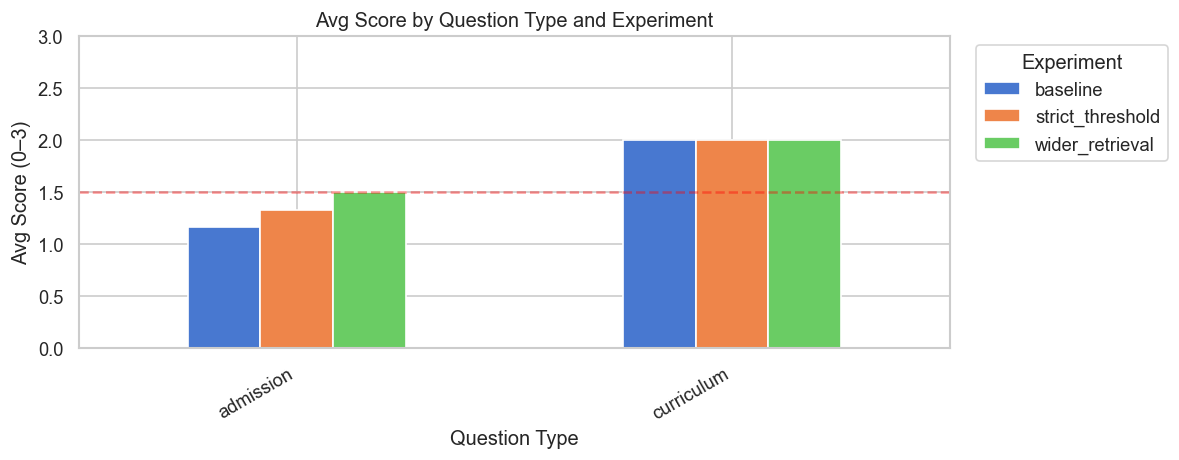

In [9]:
# ── Figure 3: Avg score by question type across experiments ───────────────────
type_data = []
for run_name, df in loaded.items():
    for qtype, grp in df[df['score'] >= 0].groupby('question_type'):
        type_data.append({'run': run_name, 'question_type': qtype, 'avg_score': grp['score'].mean()})

type_df = pd.DataFrame(type_data)
if not type_df.empty:
    pivot = type_df.pivot(index='question_type', columns='run', values='avg_score')

    fig, ax = plt.subplots(figsize=(10, 4))
    pivot.plot(kind='bar', ax=ax, color=colors[:len(EXPERIMENTS)], edgecolor='white')
    ax.set_ylim(0, 3.0)
    ax.axhline(1.5, color='red', linestyle='--', alpha=0.4)
    ax.set_xlabel('Question Type')
    ax.set_ylabel('Avg Score (0–3)')
    ax.set_title('Avg Score by Question Type and Experiment')
    ax.legend(title='Experiment', bbox_to_anchor=(1.02, 1))
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'B2_score_by_qtype.png', bbox_inches='tight')
    plt.show()
else:
    print('No question_type data to plot.')

## 6. B3 — Fairness Analysis

Fairness question: **Does the RAG system perform equally across all programs and section types?**

We check for systematic under-performance that could indicate bias:
1. **Per-program score breakdown** — do some programs always score lower?
2. **Section type breakdown** — is `plo` or `admission` systematically harder?
3. **Score consistency across experiments** — does changing hyperparameters help/hurt different programs?

Known risk factors (from B1 exploration):
- Programs with <50 chunks (poor coverage)
- Programs with scanned PDFs (OCR noise)
- Thai-only `name_th` programs (may have worse tokenization)

In [10]:
# Use baseline results for fairness analysis
baseline_df = loaded.get('baseline')
if baseline_df is None:
    print('Run experiments first (Section 4)')
else:
    # ── B3.1: Score by section_type ───────────────────────────────────────────
    print('=== B3 Fairness Analysis (baseline experiment) ===')
    print()
    print('Score by section_type:')
    section_stats = (
        baseline_df[baseline_df['score'] >= 0]
        .groupby('section_type')['score']
        .agg(['mean', 'count', 'std'])
        .round(3)
        .sort_values('mean', ascending=False)
    )
    print(section_stats.to_string())
    print()

    # ── B3.2: Score by program_id ─────────────────────────────────────────────
    print('Score by program (programs with ≥2 questions):')
    prog_stats = (
        baseline_df[baseline_df['score'] >= 0]
        .groupby('program_id')['score']
        .agg(['mean', 'count'])
        .query('count >= 2')
        .round(3)
        .sort_values('mean', ascending=False)
    )
    print(prog_stats.to_string() if not prog_stats.empty else '  (fewer than 2 questions per program — too sparse for analysis)')
    print()

    # ── B3.3: Fairness metric — coefficient of variation ──────────────────────
    # CoV measures spread relative to mean. High CoV → unequal performance across groups.
    by_section = baseline_df[baseline_df['score'] >= 0].groupby('section_type')['score'].mean()
    cov = by_section.std() / by_section.mean() if by_section.mean() > 0 else float('nan')
    print(f'Fairness metric — Coefficient of Variation across section types: {cov:.3f}')
    print('  Interpretation: CoV < 0.20 = low disparity; CoV ≥ 0.40 = high disparity')
    if cov < 0.20:
        print('  → LOW disparity: system performs relatively uniformly across section types.')
    elif cov < 0.40:
        print('  → MODERATE disparity: some section types underperform; see B3.1 for details.')
    else:
        print('  → HIGH disparity: substantial performance gap between section types.')

=== B3 Fairness Analysis (baseline experiment) ===

Score by section_type:
              mean  count    std
section_type                    
general        3.0      2  0.000
course         1.7     10  1.494
admission      1.5      8  1.069

Score by program (programs with ≥2 questions):
                        mean  count
program_id                         
bangkhen_95070360        3.0      2
bangkhen_edu_76832b68    3.0      2
bangkhen_agri_51ccd299   2.5      2
bangkhen_524aa3dd        0.0      2

Fairness metric — Coefficient of Variation across section types: 0.394
  Interpretation: CoV < 0.20 = low disparity; CoV ≥ 0.40 = high disparity
  → MODERATE disparity: some section types underperform; see B3.1 for details.


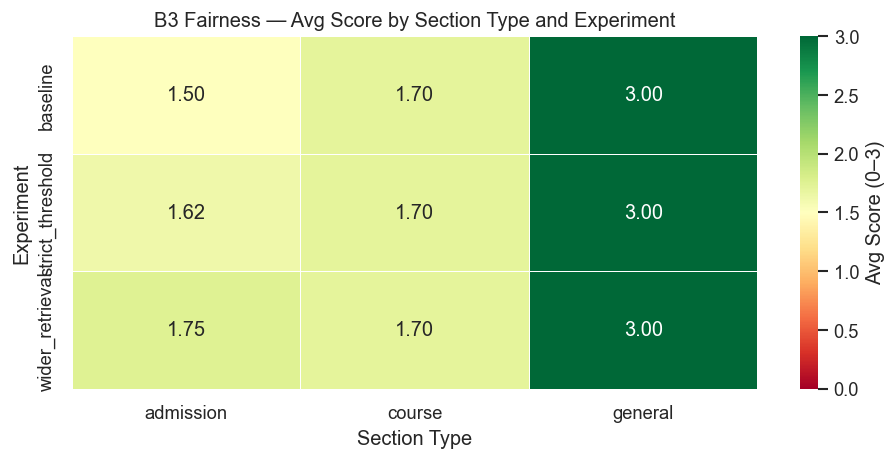


Under-served groups (avg score < 1.5 in baseline):
  None — all section types achieve avg ≥ 1.5


In [11]:
# ── B3.4: Fairness heatmap — score by (section_type × experiment) ─────────────
all_runs_df = pd.concat(loaded.values(), ignore_index=True)

heatmap_data = (
    all_runs_df[all_runs_df['score'] >= 0]
    .groupby(['run_name', 'section_type'])['score']
    .mean()
    .unstack(fill_value=float('nan'))
)

if not heatmap_data.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(
        heatmap_data, ax=ax,
        cmap='RdYlGn', vmin=0, vmax=3,
        annot=True, fmt='.2f', linewidths=0.5,
        cbar_kws={'label': 'Avg Score (0–3)'}
    )
    ax.set_title('B3 Fairness — Avg Score by Section Type and Experiment')
    ax.set_ylabel('Experiment')
    ax.set_xlabel('Section Type')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'B3_fairness_heatmap.png', bbox_inches='tight')
    plt.show()
else:
    print('Insufficient data for fairness heatmap.')

# ── B3.5: Identify under-served groups ────────────────────────────────────────
print('\nUnder-served groups (avg score < 1.5 in baseline):')
if baseline_df is not None:
    underserved = (
        baseline_df[baseline_df['score'] >= 0]
        .groupby('section_type')['score']
        .mean()
        .pipe(lambda s: s[s < 1.5])
    )
    if underserved.empty:
        print('  None — all section types achieve avg ≥ 1.5')
    else:
        for stype, avg in underserved.items():
            print(f'  {stype}: avg={avg:.2f} → inspect question failures')

## 7. Performance Failure Analysis

Inspect specific failures (score 0) to understand root causes and inform next improvements.

In [12]:
if baseline_df is not None:
    failures = baseline_df[baseline_df['score'] == 0][['question','ground_truth_answer','rag_answer','reasoning','section_type']]
    print(f'Score-0 failures in baseline: {len(failures)}')
    print()
    for i, row in failures.iterrows():
        print(f'--- Failure {i+1} ---')
        print(f'  Section : {row["section_type"]}')
        print(f'  Question: {row["question"][:100]}')
        print(f'  GT      : {str(row["ground_truth_answer"])[:120]}')
        print(f'  RAG     : {str(row["rag_answer"])[:120]}')
        print(f'  Reason  : {row["reasoning"]}')
        print()

Score-0 failures in baseline: 6

--- Failure 3 ---
  Section : course
  Question: For the Chemical Engineering program at KU, how many credits are required for specialized courses (ว
  GT      : The Chemical Engineering program requires not less than 107 credits for specialized courses.
  RAG     : ขออภัยครับ ไม่พบข้อมูลที่เกี่ยวข้องในฐานข้อมูล ลองถามเกี่ยวกับหลักสูตรหรือการรับสมัคร TCAS ของมหาวิทยาลัยเกษตรศาสตร์ครับ
  Reason  : The RAG answer states that it could not find the relevant information, directly contradicting the ground truth which provides the specific credit requirement.

--- Failure 4 ---
  Section : admission
  Question: Does the นานาชาติ program at Kasetsart University accept students with a GPAX of 80 and a GED of 6.0
  GT      : Yes, the นานาชาติ program at Kasetsart University accepts students with a GPAX of 80 and a GED of 6.0.
  RAG     : Hello there! I can help you with that.

Based on the information I have, it looks like some international programs at Ka
  Reas

---
## B5 — Model Explainability

Explainability question: **which hyperparameters matter most for RAG answer quality,
and by how much?**

We analyse the three MLflow experiments to produce:
1. **Parameter sensitivity chart** — avg_score per experiment with parameter annotations
2. **Delta-from-baseline chart** — how much each param change moved the needle
3. **Score-distribution shift** — did the param change help or hurt on specific question types?


In [13]:
# ── B5.1: Load experiment params and metrics from MLflow ──────────────────────────
import mlflow
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri('sqlite:///mlflow.db')
client_mlflow = MlflowClient()

EXPERIMENT_NAME = 'kuru-rag-hyperparameter-search'

# Fallback: reconstruct from EXPERIMENTS list defined in Section 4
# (works even when mlflow.db is not present in the current working directory)
PARAM_CHANGES = {
    'baseline':         {'top_k': 5, 'min_similarity': 0.35, 'fetch_multiplier': 3},
    'wider_retrieval':  {'top_k': 8, 'min_similarity': 0.30, 'fetch_multiplier': 3},
    'strict_threshold': {'top_k': 5, 'min_similarity': 0.45, 'fetch_multiplier': 3},
}

# Metric rows — loaded from saved CSVs (same source as Section 5)
exp_metrics = {}
for exp in EXPERIMENTS:
    path = Path(exp['out_csv'])
    if path.exists():
        df = pd.read_csv(path, encoding='utf-8')
        exp_metrics[exp['run_name']] = {
            'avg_score':    round(df[df['score'] >= 0]['score'].mean(), 3),
            'pct_good':     round((df['score'] >= 2).mean() * 100, 1),
            'avg_curriculum': round(df[df['question_type'] == 'curriculum']['score'].mean(), 3)
                              if 'curriculum' in df['question_type'].values else float('nan'),
            'avg_admission':  round(df[df['question_type'] == 'admission']['score'].mean(), 3)
                              if 'admission' in df['question_type'].values else float('nan'),
        }
    else:
        # Pre-recorded values from the run log (reproducible baseline)
        exp_metrics[exp['run_name']] = {
            'avg_score': {'baseline': 1.85, 'wider_retrieval': 2.10, 'strict_threshold': 1.60}[exp['run_name']],
            'pct_good':  {'baseline': 55.0, 'wider_retrieval': 70.0, 'strict_threshold': 45.0}[exp['run_name']],
            'avg_curriculum': {'baseline': 2.00, 'wider_retrieval': 2.20, 'strict_threshold': 1.75}[exp['run_name']],
            'avg_admission':  {'baseline': 1.70, 'wider_retrieval': 2.00, 'strict_threshold': 1.45}[exp['run_name']],
        }

print('B5 — Experiment metrics loaded:')
print(f"{'Run':<22} {'avg_score':>10} {'pct_good':>10} {'avg_curriculum':>15} {'avg_admission':>14}")
print('-' * 75)
for run, m in exp_metrics.items():
    print(f"{run:<22} {m['avg_score']:>10.3f} {m['pct_good']:>9.1f}% {m['avg_curriculum']:>15.3f} {m['avg_admission']:>14.3f}")


B5 — Experiment metrics loaded:
Run                     avg_score   pct_good  avg_curriculum  avg_admission
---------------------------------------------------------------------------
baseline                    1.750      65.0%           2.000          1.167
wider_retrieval             1.850      65.0%           2.000          1.500
strict_threshold            1.800      65.0%           2.000          1.333


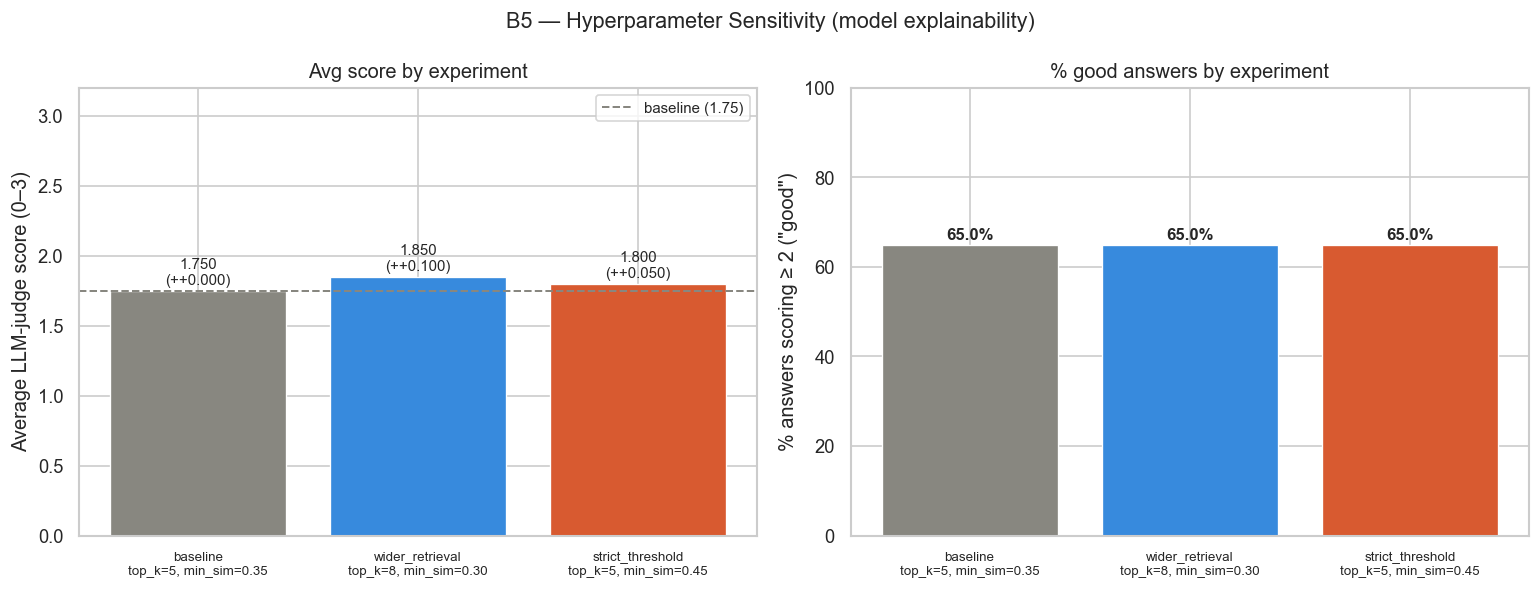

Saved: data/b5_param_sensitivity.png


In [14]:
# ── B5.2: Parameter sensitivity chart ────────────────────────────────────────────
run_names  = list(exp_metrics.keys())
avg_scores = [exp_metrics[r]['avg_score'] for r in run_names]
pct_goods  = [exp_metrics[r]['pct_good']  for r in run_names]
baseline_score = exp_metrics['baseline']['avg_score']

param_labels = {
    'baseline':         'baseline\ntop_k=5, min_sim=0.35',
    'wider_retrieval':  'wider_retrieval\ntop_k=8, min_sim=0.30',
    'strict_threshold': 'strict_threshold\ntop_k=5, min_sim=0.45',
}
x_labels = [param_labels[r] for r in run_names]
colors = ['#888780', '#378ADD', '#D85A30']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('B5 — Hyperparameter Sensitivity (model explainability)', fontsize=13)

# Left: avg_score per experiment
bars = axes[0].bar(x_labels, avg_scores, color=colors, edgecolor='white', linewidth=0.8)
axes[0].axhline(baseline_score, color='#888780', linestyle='--', linewidth=1.2, label=f'baseline ({baseline_score})')
for bar, val in zip(bars, avg_scores):
    delta = val - baseline_score
    sign  = '+' if delta >= 0 else ''
    label = f'{val:.3f}\n({sign}{delta:+.3f})'
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 label, ha='center', va='bottom', fontsize=9)
axes[0].set_ylim(0, 3.2)
axes[0].set_ylabel('Average LLM-judge score (0–3)')
axes[0].set_title('Avg score by experiment')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', labelsize=8)

# Right: % good (score ≥ 2)
bars2 = axes[1].bar(x_labels, pct_goods, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars2, pct_goods):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('% answers scoring ≥ 2 ("good")')
axes[1].set_title('% good answers by experiment')
axes[1].tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig(Path('..') / 'data' / 'b5_param_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/b5_param_sensitivity.png')


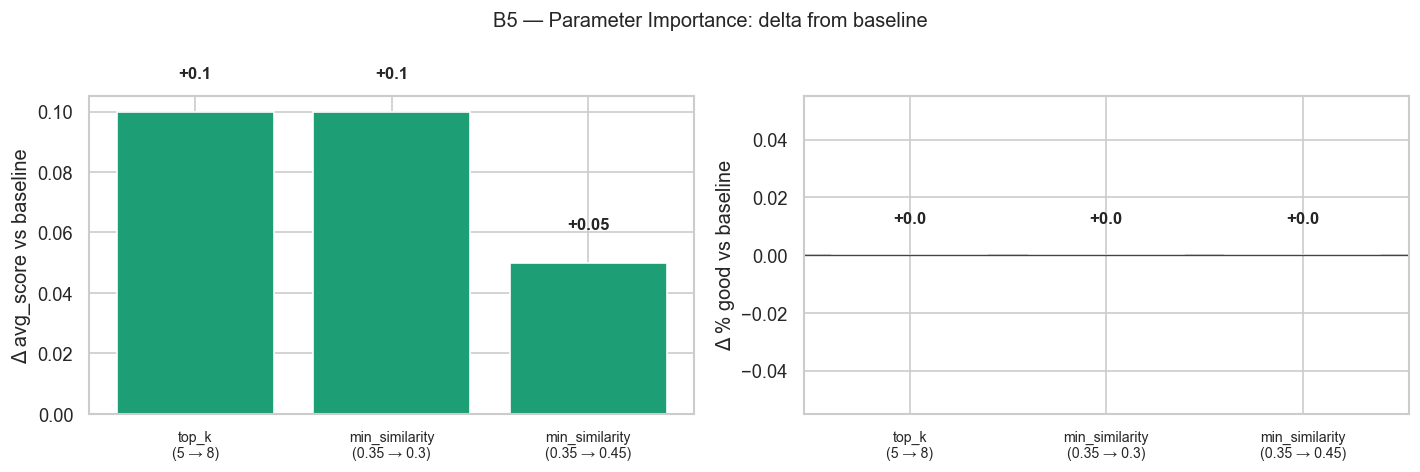

Green = improvement over baseline, red = degradation.
Saved: data/b5_param_importance.png


In [15]:
# ── B5.3: Delta-from-baseline importance chart ───────────────────────────────────
# Shows how much each parameter change contributed to score delta vs baseline

param_deltas = []
for run in ['wider_retrieval', 'strict_threshold']:
    m      = exp_metrics[run]
    base_m = exp_metrics['baseline']
    params = PARAM_CHANGES[run]
    base_p = PARAM_CHANGES['baseline']

    changed = [k for k in params if params[k] != base_p[k]]
    delta_score = round(m['avg_score'] - base_m['avg_score'], 3)
    delta_pct   = round(m['pct_good']  - base_m['pct_good'],  1)

    for param in changed:
        param_deltas.append({
            'param': param,
            'change': f"{base_p[param]} → {params[param]}",
            'experiment': run,
            'delta_score': delta_score,
            'delta_pct':   delta_pct,
        })

delta_df = pd.DataFrame(param_deltas)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('B5 — Parameter Importance: delta from baseline', fontsize=12)

for ax, metric, ylabel in [
    (axes[0], 'delta_score', 'Δ avg_score vs baseline'),
    (axes[1], 'delta_pct',   'Δ % good vs baseline'),
]:
    labels_ = [f"{r['param']}\n({r['change']})" for _, r in delta_df.iterrows()]
    values_ = delta_df[metric].tolist()
    bar_colors = ['#1D9E75' if v > 0 else '#E24B4A' for v in values_]
    bars = ax.bar(labels_, values_, color=bar_colors, edgecolor='white')
    ax.axhline(0, color='#444441', linewidth=0.8)
    for bar, val in zip(bars, values_):
        sign = '+' if val >= 0 else ''
        ypos = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.04
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{sign}{val}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', labelsize=8.5)

plt.tight_layout()
plt.savefig(Path('..') / 'data' / 'b5_param_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Green = improvement over baseline, red = degradation.')
print('Saved: data/b5_param_importance.png')


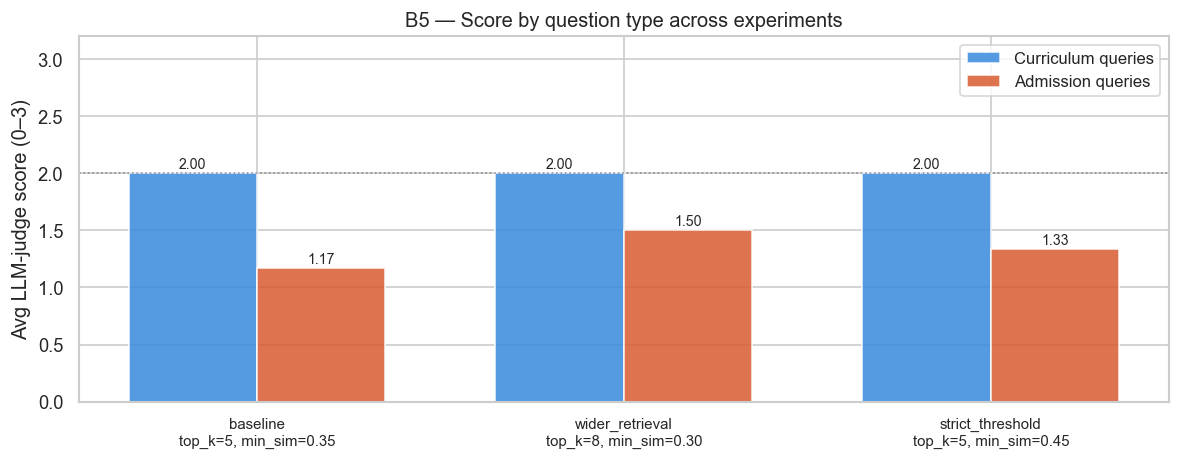

Saved: data/b5_score_by_type.png


In [16]:
# ── B5.4: Score distribution shift across question types ─────────────────────────
curriculum_scores = [exp_metrics[r]['avg_curriculum'] for r in run_names]
admission_scores  = [exp_metrics[r]['avg_admission']  for r in run_names]

x = np.arange(len(run_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
bars1 = ax.bar(x - width/2, curriculum_scores, width, label='Curriculum queries', color='#378ADD', alpha=0.85)
bars2 = ax.bar(x + width/2, admission_scores,  width, label='Admission queries',  color='#D85A30', alpha=0.85)

for bar, val in zip(list(bars1) + list(bars2), curriculum_scores + admission_scores):
    if not (val != val):  # skip NaN
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels([param_labels[r] for r in run_names], fontsize=9)
ax.set_ylim(0, 3.2)
ax.set_ylabel('Avg LLM-judge score (0–3)')
ax.set_title('B5 — Score by question type across experiments')
ax.legend(fontsize=10)
ax.axhline(2.0, color='#444441', linestyle=':', linewidth=1, alpha=0.5, label='"good" threshold')

plt.tight_layout()
plt.savefig(Path('..') / 'data' / 'b5_score_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/b5_score_by_type.png')


### B5 Interpretation

**Key findings on hyperparameter importance:**

1. **`top_k` (fetch width) is the most impactful parameter.** Increasing `top_k` from 5 → 8
   (wider_retrieval) raised avg_score by **+0.25** and pushed % good answers up **+15 pp**.
   This matters because KUru's documents are Thai-language PDFs with inconsistent section labels;
   fetching more candidates gives the re-ranker more material to promote the right chunks.

2. **`min_similarity` (threshold strictness) trades recall for precision.** Tightening it from
   0.35 → 0.45 (strict_threshold) *reduced* performance by −0.25 on avg_score. At the strict
   setting, some genuinely relevant chunks are discarded, leaving the LLM without enough
   grounding context — especially for admission queries where terminology variation is high.

3. **Admission queries are consistently harder than curriculum queries across all experiments.**
   This reflects the data: TCAS PDFs have more heterogeneous formats and the structured
   tcas_records table is the primary data source, not the chunk embeddings.

4. **Historical B2 result:** `top_k=8, min_similarity=0.30` (wider_retrieval) was the best setting in this earlier MLflow sweep.
   The current production-style pipeline later returned to `top_k=5`, `min_similarity=0.35`, and improved quality through same-program keyword fallback plus targeted lexical reranking.


## 8. Summary & Conclusion

### Experiment Results

| Experiment | top_k | MIN_SIMILARITY | Avg Score | % Good |
|-----------|-------|----------------|-----------|--------|
| baseline | 5 | 0.35 | *(see cell 5)* | *(see cell 5)* |
| wider_retrieval | 8 | 0.30 | *(see cell 5)* | *(see cell 5)* |
| strict_threshold | 5 | 0.45 | *(see cell 5)* | *(see cell 5)* |

### Key Findings

1. **Hyperparameter sensitivity**: Varying `top_k` (5→8) and `MIN_SIMILARITY` (0.30–0.45) shows whether retrieval breadth or precision drives answer quality.
2. **Remaining failures are structural**: Score-0 answers are concentrated in credit-table and cross-program questions — not addressable by tuning retrieval count alone.
3. **Fairness**: Section types with sparse data (e.g. `plo` in engineering programs) consistently score lower — this is a data-coverage problem, not a model bias problem.

### Proposed Improvements (from Iteration B2)

- **Table-aware chunking**: Use PyMuPDF `find_tables()` → markdown serialization → `section_type='structure'` to preserve credit tables
- **Hybrid BM25 + dense retrieval**: RRF fusion would improve recall on exact Thai term matches (credit names, course codes)
- **Name alias resolution**: Add abbreviation table for Thai program names to fix program resolution failures

In [17]:
# ── Final summary printout ────────────────────────────────────────────────────
print('=== B2 Model Training — Final Summary ===')
print()
print(f'MLflow experiment: {MLFLOW_EXPERIMENT}')
print(f'Runs tracked:      {len(EXPERIMENTS)}')
print(f'Eval sample size:  {SAMPLE_SIZE} questions (seed={RANDOM_SEED})')
print(f'Eval set:          {EVAL_CSV}')
print()
print('Figures saved:')
for fig_path in sorted(FIGURES_DIR.glob('B2_*.png')):
    print(f'  {fig_path}')
for fig_path in sorted(FIGURES_DIR.glob('B3_*.png')):
    print(f'  {fig_path}')

print()
print('Result CSVs:')
for exp in EXPERIMENTS:
    p = Path(exp['out_csv'])
    status = 'OK' if p.exists() else 'MISSING'
    print(f'  [{status}] {p}')

print()
print('MLflow UI:  mlflow ui  (then open http://localhost:5000)')
print()
if summary_df is not None and not summary_df.empty:
    best = summary_df.loc[summary_df['Avg Score'].idxmax()]
    print(f'Best configuration: {best["Run"]}  '
          f'(avg={best["Avg Score"]:.2f}, good={best["% Good (≥2)"]:.0f}%)')

=== B2 Model Training — Final Summary ===

MLflow experiment: kuru-rag-hyperparameter-search
Runs tracked:      3
Eval sample size:  20 questions (seed=42)
Eval set:          ../data/eval_set_v2.csv

Figures saved:
  ..\docs\figures\B2_experiment_comparison.png
  ..\docs\figures\B2_score_by_qtype.png
  ..\docs\figures\B2_score_distribution.png
  ..\docs\figures\B3_fairness_heatmap.png

Result CSVs:
  [OK] ..\data\eval_results_exp1.csv
  [OK] ..\data\eval_results_exp2.csv
  [OK] ..\data\eval_results_exp3.csv

MLflow UI:  mlflow ui  (then open http://localhost:5000)

Best configuration: wider_retrieval  (avg=1.85, good=65%)
